# Battery State-of-Health Estimation from Electrochemical Impedance using Reduced Measurements

This notebook contains the complete analysis pipeline used to produce the results presented in the accompanying article *Battery State-of-Health Estimation from Electrochemical Impedance using Reduced Measurements*.

The code reproduces the main steps of the study, including:

* loading and preprocessing the LiBforSecUse dataset;
* principal component analysis (PCA);
* implementation of the machine learning models;
* nested group cross-validation for model selection and performance evaluation;
* domain-guided frequency selection and reduction of the EIS feature space;
* generation of the figures and quantitative results reported in the manuscript.

The objective of the study is to investigate whether battery state-of-health (SOH) can be accurately estimated from a substantially reduced set of electrochemical impedance spectroscopy (EIS) measurements. The analysis shows that, for the dataset considered, strongly reduced frequency representations retain predictive performance comparable to the full-frequency representation across several regression algorithms, while substantially reducing the number of measurements..

The code is organized to facilitate reproducibility of the published results. Unless otherwise stated, all analyses, figures, and performance metrics reported in the article can be reproduced from this notebook.

## Preparation

### Import packages

Importation of python libraries, definition of color schemes

In [1]:
import os
import numpy as np
import scipy.stats as ss
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, clear_output
%matplotlib inline
import matplotlib.font_manager
%config InlineBackend.figure_format = 'retina'
%matplotlib inline
plt.style.use('./METAS.mplstyle')
plt.rcParams["font.size"] = 12

from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import GroupKFold

from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor

from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error

(CMETblue, CMETred, CMETyellow, CFEDred,  CMETorange, CMETgold, CMEToil, CMETturquoise, CMETgreen, CMETviolet, CMETblack, CMETgrey) = plt.rcParams['axes.prop_cycle'].by_key()['color']

## Data

### Loading data 

The preprocessed dataset can be download from Zenodo : https://zenodo.org/records/17792537. 

Once the file is saved in a local folder, we can load it into Python.

In [2]:
os.chdir("C:\\Users\\gufa\\Downloads\\17792537")

In [3]:
# Load data.
df = pd.read_csv("./frequency-space_spline-interp_v1-3.txt", index_col=0)
df.head()

,LCT_ID,Institution,T_cycle_degC,SOC_cycle_high,DOD_cycle,Cell_ID,nCycle,SOC,nFreqExp_EIS,Qcap_mAh,...,Z_real@10^3.6_Hz,Z_imag@10^3.6_Hz,Z_real@10^3.7_Hz,Z_imag@10^3.7_Hz,Z_real@10^3.8_Hz,Z_imag@10^3.8_Hz,Z_real@10^3.9_Hz,Z_imag@10^3.9_Hz,Z_real@10^4.0_Hz,Z_imag@10^4.0_Hz
exp_ID,,,,,,,,,,,,,,,,,,,,,
Inst1-04_0_100,1_02,Institution 1,45,100,100,Inst1-04,0,100,61,2696.22,...,0.014401,0.005009,0.014441,0.006529,0.014551,0.008389,0.014728,0.010656,0.014994,0.013422
Inst1-04_50_100,1_02,Institution 1,45,100,100,Inst1-04,50,100,61,2567.82,...,0.014579,0.005147,0.014616,0.006693,0.014726,0.008585,0.014899,0.010894,0.015160,0.013720
Inst1-04_100_100,1_02,Institution 1,45,100,100,Inst1-04,100,100,61,2525.20,...,0.014749,0.005037,0.014790,0.006556,0.014899,0.008413,0.015071,0.010677,0.015330,0.013448
Inst1-04_150_100,1_02,Institution 1,45,100,100,Inst1-04,150,100,61,2484.72,...,0.014835,0.005020,0.014871,0.006531,0.014978,0.008381,0.015151,0.010641,0.015408,0.013400
Inst1-04_200_100,1_02,Institution 1,45,100,100,Inst1-04,200,100,60,2459.30,...,0.014928,0.005157,0.014970,0.006701,0.015079,0.008589,0.015251,0.010895,NaN,NaN


### Data set used for the analysis (Section 2.2 of the paper, last paragraph)

#### Discard some variables due to missing values 

We remove frequencies $10^{-2.0}$, $10^{-1.9}$, and $10^{4.0}$ Hz. The input space is then made of 116 EIS variables.

In [4]:
df = df.drop(columns=["Z_real@10^-2.0_Hz", "Z_imag@10^-2.0_Hz", "Z_real@10^-1.9_Hz", "Z_imag@10^-1.9_Hz", "Z_real@10^4.0_Hz", "Z_imag@10^4.0_Hz"])

#### Experiment removals 

We remove the 9 experiments conducted at SOC = 25. 

In [5]:
df = df[df.SOC!=25]

In [6]:
df.shape

(4288, 127)

## Principal component analysis (PCA, Section 2.3 of the paper)

In [7]:
# Prep data
EIS_data = df[df.columns[11:]]
scaler = MinMaxScaler(feature_range = (-1, 1))
EIS_data = scaler.fit_transform(EIS_data)

# PCA computations
pca = PCA(n_components=116, random_state = 42)  
principal_components = pca.fit_transform(EIS_data)

principal_components[:, 0] = -principal_components[:, 0]  # Score sign change
pca.components_[0] = -pca.components_[0]                  # Loadings sign change

# Results DataFrame
comp_name = ['PC' + str (i+1) for i in range(116)]
pca_df = pd.DataFrame(data=principal_components,
    columns=comp_name)
pca_df["SOH"] = df["SOH"].values


Figure 1 of the paper.

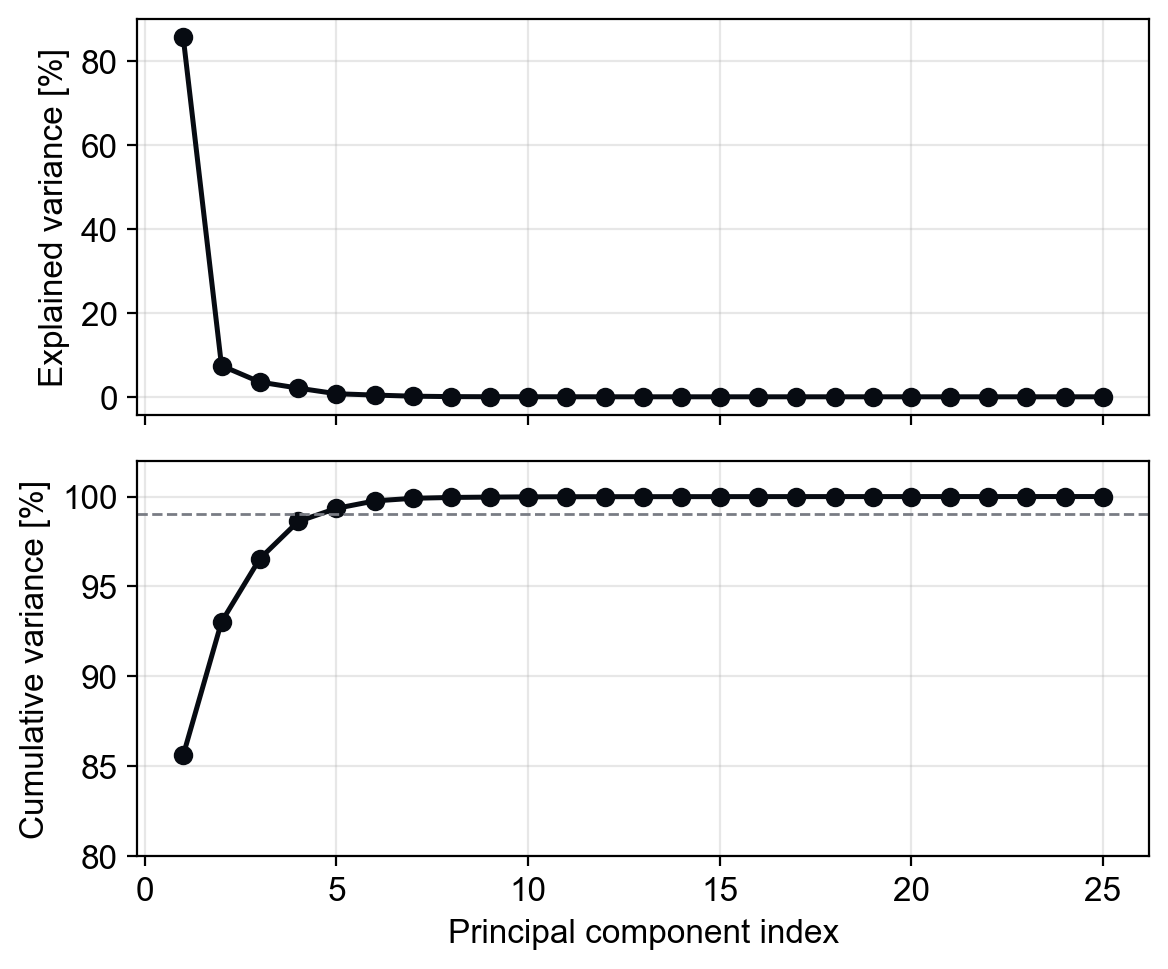

In [8]:
explained_variance_116 = np.array(pca.explained_variance_ratio_[:25] * 100)
cumulative_variance_116 = np.cumsum(explained_variance_116)
components_116 = np.arange(1, len(explained_variance_116) + 1)

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(6, 5), sharex=True, gridspec_kw={"height_ratios": [1, 1]})

axes[0].plot(components_116, explained_variance_116, marker="o", linewidth=1.8, color=CMETblack)
axes[0].set_ylabel("Explained variance [%]")
axes[0].grid(alpha=0.3)

axes[1].plot(components_116, cumulative_variance_116, marker="o", linewidth=1.8, color=CMETblack)
axes[1].axhline(99, linestyle="--", linewidth=1, color = CMETgrey)

axes[1].set_xlabel("Principal component index")
axes[1].set_ylabel("Cumulative variance [%]")
axes[1].set_ylim(80, 102)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("scree.png", dpi = 300, format = "png")
plt.show()


Figure 2 of the paper.

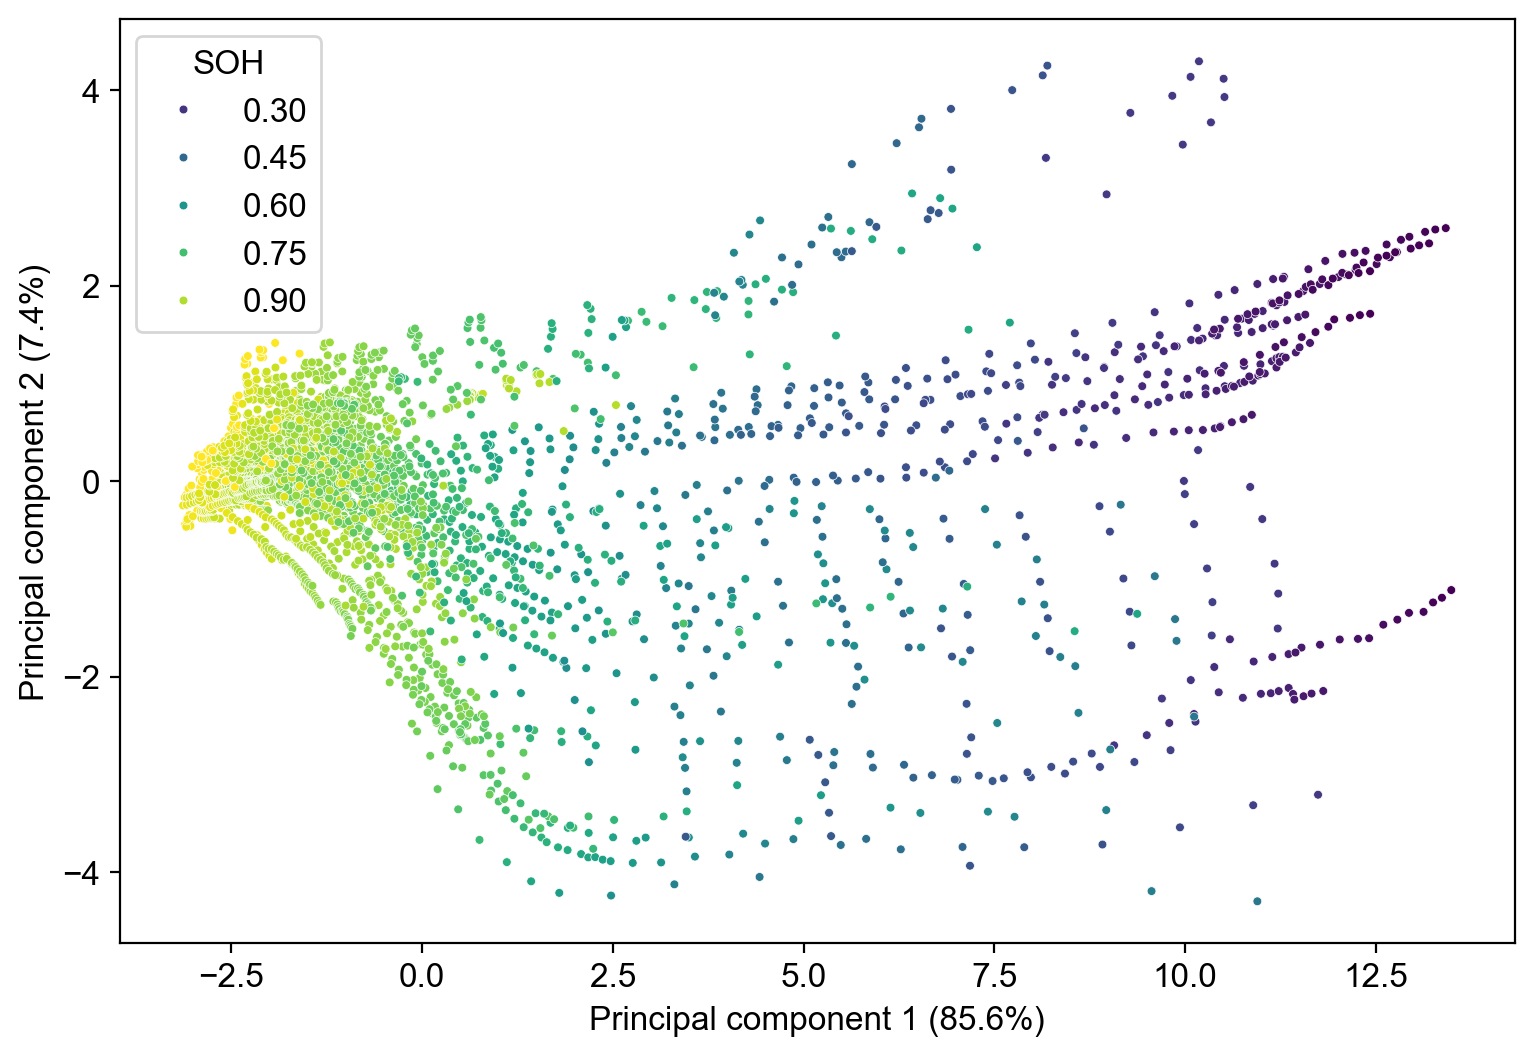

In [9]:
# Figure article / poster
plt.figure(figsize = (9, 6))
sns.scatterplot(x='PC1', y='PC2', hue = "SOH", s=10 ,palette="viridis", data = pca_df)
plt.xlabel(f'Principal component 1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'Principal component 2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.legend(loc=2, title="SOH")
plt.savefig("pca.png", dpi = 300, format = "png")
plt.show()

In [10]:
print("Kendall's tau:", ss.kendalltau(pca_df["PC1"].values, pca_df["SOH"]))
print("Spearman's rho:", ss.spearmanr(pca_df["PC1"].values, pca_df["SOH"]))

Kendall's tau: SignificanceResult(statistic=-0.7146269767543845, pvalue=0.0)
Spearman's rho: SignificanceResult(statistic=-0.8769129622689374, pvalue=0.0)


## Modeling

Select all EIS variables

In [11]:
X = EIS_data
y = df.loc[:, "SOH"].values
groups = df.loc[:, "Cell_ID"]

Hyperparameter search space, Table 2 of the paper.

In [12]:
# Models and hyper-parameter grids
model_configs = {
    'Linear_Regression' : {
        'model' : LinearRegression(),
        'param_grid' : {}
    },
    'Ridge_Regression' : {
        'model' : Ridge(),
        'param_grid' : {'model__alpha': np.logspace(-8, 2, 100)}
    },
    'kNN' : {
        'model' : KNeighborsRegressor(),
        'param_grid' : {'model__n_neighbors': np.arange(1, 200, 1), 'model__p' : [2]}
    },
    'Random_Forest' : {
        'model' : RandomForestRegressor(),
        'param_grid' : {'model__n_estimators': [500], 'model__max_features': ["log2"], 'model__random_state':[41]}
    },
    'SVR' : {
        'model' : SVR(),
        'param_grid' : {'model__C': np.logspace(-3, 3, 7), 'model__epsilon': np.logspace(-4, -1, 7)}
    },
    'MLP' : {    
        'model': MLPRegressor(), 
        'param_grid' : {'model__hidden_layer_sizes': [(50, 50)], 'model__activation':["relu"], 
     'model__solver':["adam"], 'model__max_iter':[500], 'model__random_state':[42], 'model__alpha':np.logspace(-3, 0, 50)}
     }
}

Nested grouped cross-validation scheme

In [13]:
# Cross-validation Schemes
outer_rep = GroupKFold(n_splits=5, shuffle=True, random_state=12)    
inner_loop = GroupKFold(n_splits = 5, shuffle=True, random_state=13)

### With all features

In [ ]:
# Results
score_trn = {name: np.zeros(outer_rep.get_n_splits()) for name in model_configs}
score_val = {name: np.zeros(outer_rep.get_n_splits()) for name in model_configs}
score_tst = {name: np.zeros(outer_rep.get_n_splits()) for name in model_configs}
best_param = {name: [] for name in model_configs}

# Outer Loop
i=0
for trn_idx, tst_idx in outer_rep.split(X, y, groups=groups):    
    for name, cfg in model_configs.items() :
        # Pipeline
        pipeline = Pipeline([('scaler', MinMaxScaler(feature_range = (-1, 1))), ('model', cfg['model'])])

        # Inner Loop
        grid = GridSearchCV(estimator=pipeline, param_grid=cfg['param_grid'], 
                            verbose=0, cv = inner_loop, n_jobs = -1, scoring = 'neg_mean_squared_error', refit = True)
        grid.fit(X[trn_idx,:], y[trn_idx], groups = groups.iloc[trn_idx])
    
        # Collecting Results
        best_param[name].append(grid.best_params_)
        score_trn[name][i] = grid.score(X[trn_idx,:], y[trn_idx]) #attention score refit
        score_val[name][i] = grid.best_score_
        score_tst[name][i] = grid.score(X[tst_idx,:], y[tst_idx]) #attention score refit
        
    i += 1

In [ ]:
print("\nResults : \n")
for name in model_configs.keys():
    print(f"{name}:")
    print("   Train RMSE:", f"{np.sqrt(-score_trn[name]).mean():.4f}", "\u00B1", f"{np.sqrt(-score_trn[name]).std():.4f}")
    print("   Val RMSE:", f"{np.sqrt(-score_val[name]).mean():.4f}", "\u00B1", f"{np.sqrt(-score_val[name]).std():.4f}")
    print("   Test RMSE:", f"{np.sqrt(-score_tst[name]).mean():.4f}", "\u00B1", f"{np.sqrt(-score_tst[name]).std():.4f}")
    print("")
    print(f"   Test RMSE on each split: {np.sqrt(-score_tst[name])}")
    print(f"   Hyperparameters : ")
    for l in best_param[name] :
        print(f"      {l}") 


Results : 

Linear_Regression:
   Train RMSE: 0.0277 ± 0.0009
   Val RMSE: 0.0457 ± 0.0069
   Test RMSE: 0.0378 ± 0.0055

   Test RMSE on each split: [0.03693542 0.04611141 0.03476116 0.04136458 0.03001066]
   Hyperparameters : 
      {}
      {}
      {}
      {}
      {}
Ridge_Regression:
   Train RMSE: 0.0297 ± 0.0020
   Val RMSE: 0.0370 ± 0.0006
   Test RMSE: 0.0357 ± 0.0036

   Test RMSE on each split: [0.03922768 0.03368575 0.03406281 0.04037174 0.03093707]
   Hyperparameters : 
      {'model__alpha': np.float64(0.011497569953977356)}
      {'model__alpha': np.float64(0.03678379771828634)}
      {'model__alpha': np.float64(0.0003511191734215127)}
      {'model__alpha': np.float64(0.014508287784959401)}
      {'model__alpha': np.float64(0.1176811952434999)}
kNN:
   Train RMSE: 0.0228 ± 0.0024
   Val RMSE: 0.0442 ± 0.0032
   Test RMSE: 0.0400 ± 0.0105

   Test RMSE on each split: [0.04098591 0.03103545 0.03113581 0.05957792 0.03722783]
   Hyperparameters : 
      {'model__n_neighb

### Remove low-frequency

Remove low-frequency under a given threshold, and build the corresponding input space

In [ ]:
X = df.loc[:, "Z_real@10^-1.0_Hz":].values #remove frequency below 10^{-1} Hz
#X = df.loc[:, "Z_real@10^0.0_Hz":].values  #remove frequency below 10^{0} Hz
#X = df.loc[:, "Z_real@10^1.0_Hz":].values  #remove frequency below 10^{1} Hz
#X = df.loc[:, "Z_real@10^2.0_Hz":].values  #remove frequency below 10^{2} Hz
#X = df.loc[:, "Z_real@10^3.0_Hz":].values  #remove frequency below 10^{3} Hz

X.shape

(4288, 20)

In [ ]:
# Results
score_trn = {name: np.zeros(outer_rep.get_n_splits()) for name in model_configs}
score_val = {name: np.zeros(outer_rep.get_n_splits()) for name in model_configs}
score_tst = {name: np.zeros(outer_rep.get_n_splits()) for name in model_configs}
best_param = {name: [] for name in model_configs}

# Outer Loop
i=0
for trn_idx, tst_idx in outer_rep.split(X, y, groups=groups):    
    for name, cfg in model_configs.items() :
        # Pipeline
        pipeline = Pipeline([('scaler', MinMaxScaler(feature_range = (-1, 1))), ('model', cfg['model'])])

        # Inner Loop
        grid = GridSearchCV(estimator=pipeline, param_grid=cfg['param_grid'], 
                            verbose=0, cv = inner_loop, n_jobs = -1, scoring = 'neg_mean_squared_error', refit = True)
        grid.fit(X[trn_idx,:], y[trn_idx], groups = groups.iloc[trn_idx])
    
        # Collecting Results
        best_param[name].append(grid.best_params_)
        score_trn[name][i] = grid.score(X[trn_idx,:], y[trn_idx]) #attention score refit
        score_val[name][i] = grid.best_score_
        score_tst[name][i] = grid.score(X[tst_idx,:], y[tst_idx]) #attention score refit    
    i += 1

In [ ]:
print("\nResults : \n")
for name in model_configs.keys():
    print(f"{name}:")
    print("   RMSE train:", f"{np.sqrt(-score_trn[name]).mean():.4f}", "\u00B1", f"{np.sqrt(-score_trn[name]).std():.4f}")
    print("   RMSE val:", f"{np.sqrt(-score_val[name]).mean():.4f}", "\u00B1", f"{np.sqrt(-score_val[name]).std():.4f}")
    print("   RMSE test:", f"{np.sqrt(-score_tst[name]).mean():.4f}", "\u00B1", f"{np.sqrt(-score_tst[name]).std():.4f}")
    print("")
    print(f"   RMSE test sur chaque split: {np.sqrt(-score_tst[name])}")
    print(f"   Hyperparamètres : ")
    for l in best_param[name] :
        print(f"      {l}") 



Results : 

Linear_Regression:
   RMSE train: 0.0544 ± 0.0014
   RMSE val: 0.0660 ± 0.0021
   RMSE test: 0.0636 ± 0.0060

   RMSE test sur chaque split: [0.06946158 0.05511645 0.06435835 0.07055084 0.05843067]
   Hyperparamètres : 
      {}
      {}
      {}
      {}
      {}
Ridge_Regression:
   RMSE train: 0.0557 ± 0.0020
   RMSE val: 0.0652 ± 0.0025
   RMSE test: 0.0663 ± 0.0099

   RMSE test sur chaque split: [0.08311822 0.05511564 0.06366579 0.0708706  0.05886986]
   Hyperparamètres : 
      {'model__alpha': np.float64(79.24828983539186)}
      {'model__alpha': np.float64(1.3530477745798076e-05)}
      {'model__alpha': np.float64(0.0007054802310718645)}
      {'model__alpha': np.float64(0.0003511191734215127)}
      {'model__alpha': np.float64(0.0014174741629268048)}
kNN:
   RMSE train: 0.0448 ± 0.0101
   RMSE val: 0.0750 ± 0.0095
   RMSE test: 0.0729 ± 0.0107

   RMSE test sur chaque split: [0.0877388  0.07390254 0.06206932 0.0809292  0.06007608]
   Hyperparamètres : 
      {'mo

#### Result summary

Figure 3 of the paper

In [ ]:
rmv_lf = {"MLA" : ["OLS", "Ridge", "k-NN", "RF", "SVR", "MLP"],
          "Features" : ["116 features\n""All frequencies", "100 features\n" + r"$\geq 10^{-1}$ Hz", "80 features\n" + r"$\geq 10^{0}$ Hz", "60 features\n" + r"$\geq 10^{1}$ Hz", "40 features\n" + r"$\geq 10^{2}$ Hz", "20 features\n" + r"$\geq 10^{3}$ Hz"],
          "RMSE" : np.array([[0.0378, 0.0352, 0.0364, 0.0368, 0.0451, 0.0636],
                             [0.0357, 0.0352, 0.0367, 0.0368, 0.0452, 0.0663],
                             [0.0400, 0.0403, 0.0389, 0.0441, 0.0600, 0.0729],
                             [0.0334, 0.0342, 0.0370, 0.0419, 0.0566, 0.0725],
                             [0.0310, 0.0317, 0.0262, 0.0296, 0.0422, 0.0669],
                             [0.0307, 0.0332, 0.0312, 0.0362, 0.0496, 0.0652]]),         
          "std" : np.array([[0.0055, 0.0030, 0.0022, 0.0026, 0.0053, 0.0060],
                            [0.0036, 0.0032, 0.0023, 0.0029, 0.0054, 0.0099],
                            [0.0105, 0.0105, 0.0080,  0.0085, 0.0116, 0.0107],
                            [0.0051, 0.0047, 0.0072, 0.0126, 0.0164, 0.0153],
                            [0.0144, 0.0131, 0.0068, 0.0048, 0.0126,0.0172],
                            [0.0023, 0.0040, 0.0061, 0.0046, 0.0083, 0.0133]]),
          "p" : [116, 100, 80, 60, 40, 20], 
          "n_freq" : [58, 50, 40, 30, 20, 10]} 

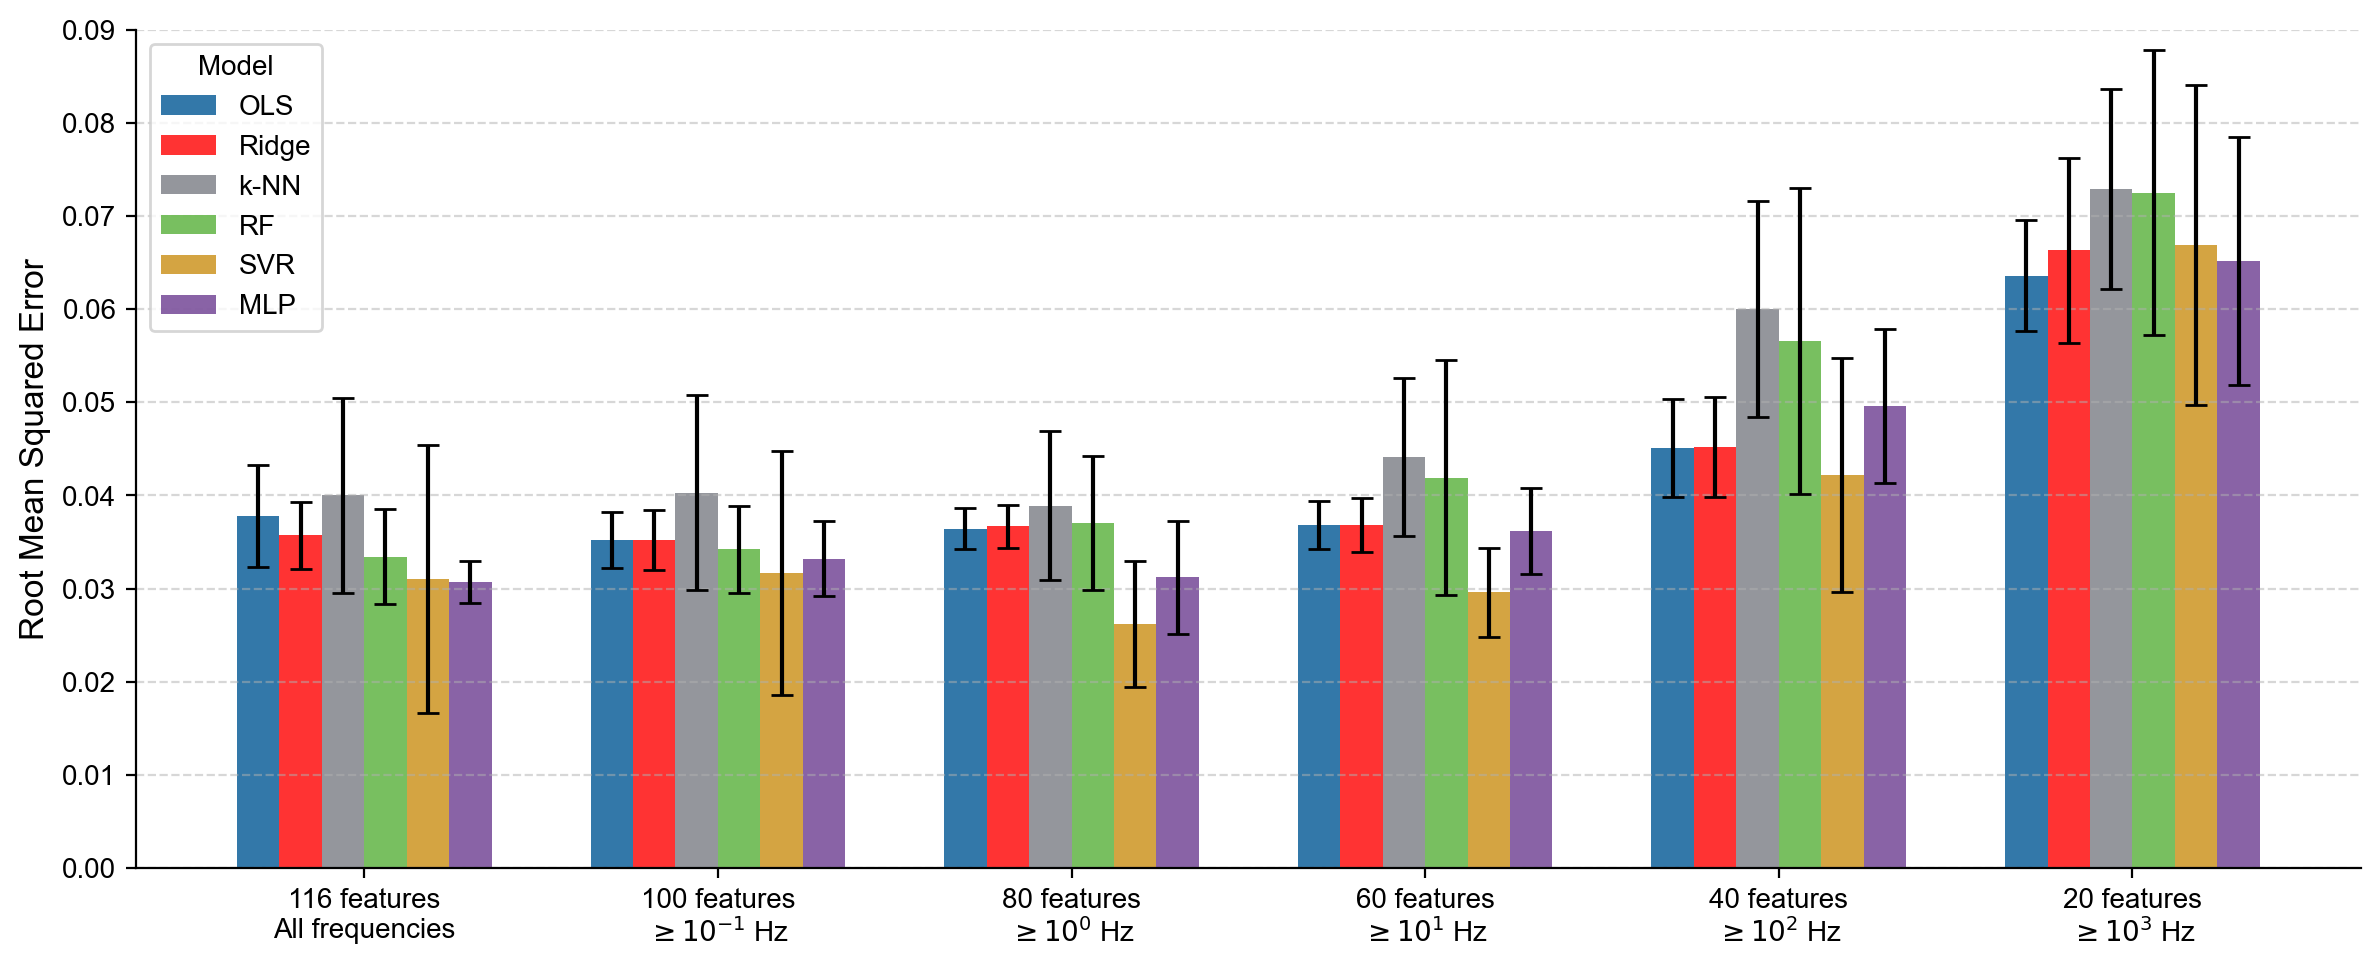

In [ ]:
color = (CMETblue, CFEDred, CMETgrey,  CMETgreen, CMETgold, CMETviolet)

# Paramètres
categories = rmv_lf["Features"]
group_labels = rmv_lf["MLA"]
n_categories = len(categories)
n_groups = len(group_labels)

# Moyennes et erreurs
means = rmv_lf["RMSE"]
errors = rmv_lf["std"]

# Positionnement des barres
x = np.arange(n_categories)
width = 0.12  # largeur des barres
offsets = np.linspace(-width*2.5, width*2.5, n_groups)  # décalages pour grouper

# Création du graphique
fig, ax = plt.subplots(figsize=(12, 5))

for i in range(n_groups):
    ax.bar(
        x + offsets[i],
        means[i],
        width,
        yerr=errors[i],
        capsize=4,
        ecolor='k', 
        label=group_labels[i],
        color=color[i],
        alpha = 0.8
    )

# Mise en forme
ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize = 10)
ax.set_ylim([0, 0.09])
ax.set_ylabel("Root Mean Squared Error", fontsize = 12)
ax.legend(title="Model", loc = 2)
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig("low_freq.png", dpi = 300, format = "png")
plt.show()

### Reduce frequency resolution on restricted range

Selecting the features involved in the predictive models

In [ ]:
## Restricted range : all frequencies between $1$ Hz and  $1000$ Hz
col = df.loc[:, "Z_real@10^0.0_Hz":"Z_imag@10^3.0_Hz"].columns                                                                     # 31 frequencies


## Decreasing of the spectral resolution within the restricted range
#col = ['Z_real@10^0.0_Hz', 'Z_imag@10^0.0_Hz', 'Z_real@10^1.0_Hz', 'Z_imag@10^1.0_Hz', 'Z_real@10^2.0_Hz', 'Z_imag@10^2.0_Hz', 'Z_real@10^3.0_Hz', 'Z_imag@10^3.0_Hz']   # 4 frequencies
#col = ['Z_real@10^0.0_Hz', 'Z_imag@10^0.0_Hz', 'Z_real@10^1.5_Hz', 'Z_imag@10^1.5_Hz', 'Z_real@10^3.0_Hz', 'Z_imag@10^3.0_Hz']                                           # 3 frequencies
#col = ['Z_real@10^0.0_Hz', 'Z_imag@10^0.0_Hz', 'Z_real@10^3.0_Hz', 'Z_imag@10^3.0_Hz']                                                                                   # 2 frequencies
#col = ['Z_real@10^1.5_Hz', 'Z_imag@10^1.5_Hz']                                                                                                                           # 1 frequencies

Build the corresponding input space

In [ ]:
X = df.loc[:, col].values
X.shape

(4288, 2)

In [ ]:
# Results
score_trn = {name: np.zeros(outer_rep.get_n_splits()) for name in model_configs}
score_val = {name: np.zeros(outer_rep.get_n_splits()) for name in model_configs}
score_tst = {name: np.zeros(outer_rep.get_n_splits()) for name in model_configs}
best_param = {name: [] for name in model_configs}

# Outer Loop
i=0
for trn_idx, tst_idx in outer_rep.split(X, y, groups=groups):
    for name, cfg in model_configs.items() :
        # Pipeline
        pipeline = Pipeline([('scaler', MinMaxScaler(feature_range = (-1, 1))), ('model', cfg['model'])])

        # Inner Loop
        grid = GridSearchCV(estimator=pipeline, param_grid=cfg['param_grid'], 
                            verbose=0, cv = inner_loop, n_jobs = -1, scoring = 'neg_mean_squared_error', refit = True)
        grid.fit(X[trn_idx,:], y[trn_idx], groups = groups.iloc[trn_idx])
    
        # Collecting Results
        best_param[name].append(grid.best_params_)
        score_trn[name][i] = grid.score(X[trn_idx,:], y[trn_idx]) #attention score refit
        score_val[name][i] = grid.best_score_
        score_tst[name][i] = grid.score(X[tst_idx,:], y[tst_idx]) #attention score refit
    i += 1

In [ ]:
print("\nResults : \n")
for name in model_configs.keys():
    print(f"{name}:")
    print("   RMSE train:", f"{np.sqrt(-score_trn[name]).mean():.4f}", "\u00B1", f"{np.sqrt(-score_trn[name]).std():.4f}")
    print("   RMSE val:", f"{np.sqrt(-score_val[name]).mean():.4f}", "\u00B1", f"{np.sqrt(-score_val[name]).std():.4f}")
    print("   RMSE test:", f"{np.sqrt(-score_tst[name]).mean():.4f}", "\u00B1", f"{np.sqrt(-score_tst[name]).std():.4f}")
    print("")
    print(f"   RMSE test sur chaque split: {np.sqrt(-score_tst[name])}")
    print(f"   Hyperparamètres : ")
    for l in best_param[name] :
        print(f"      {l}") 


Results : 

Linear_Regression:
   RMSE train: 0.0489 ± 0.0020
   RMSE val: 0.0503 ± 0.0022
   RMSE test: 0.0489 ± 0.0107

   RMSE test sur chaque split: [0.05415227 0.0428843  0.03133242 0.06188038 0.05418191]
   Hyperparamètres : 
      {}
      {}
      {}
      {}
      {}
Ridge_Regression:
   RMSE train: 0.0490 ± 0.0020
   RMSE val: 0.0502 ± 0.0021
   RMSE test: 0.0490 ± 0.0105

   RMSE test sur chaque split: [0.05415227 0.04288053 0.03189812 0.06182341 0.05435437]
   Hyperparamètres : 
      {'model__alpha': np.float64(1e-08)}
      {'model__alpha': np.float64(7.742636826811277)}
      {'model__alpha': np.float64(12.328467394420635)}
      {'model__alpha': np.float64(0.7564633275546291)}
      {'model__alpha': np.float64(3.8535285937105352)}
kNN:
   RMSE train: 0.0268 ± 0.0010
   RMSE val: 0.0423 ± 0.0027
   RMSE test: 0.0424 ± 0.0078

   RMSE test sur chaque split: [0.05270105 0.03443069 0.03388758 0.05027228 0.0407618 ]
   Hyperparamètres : 
      {'model__n_neighbors': np.int6

#### Result summary

Figure 4 of the paper

In [ ]:
sampl_freq = {"MLA" : ["OLS", "Ridge", "k-NN", "RF", "SVR", "MLP"],
          "Features" : ["116 features\n""All frequencies", "62 features\n" + r"$10^{0.0} - 10^{3.0}$ Hz", "8 features\n" + r"$10^{0.0}, 10^{1.0}, 10^{2.0}, 10^{3.0}$ Hz", "6 features\n" + r"$10^{0.0}, 10^{1.5}, 10^{3.0}$ Hz", "4 features\n" + r"$10^{0.0}, 10^{3.0}$ Hz", "2 features\n" + r"$10^{1.5}$ Hz"],
          "RMSE" : np.array([[0.0378, 0.0361, 0.0376, 0.0381, 0.0526, 0.0489],
                             [0.0357, 0.0360, 0.0380, 0.0383, 0.0526, 0.0490],
                             [0.0400, 0.0380, 0.0401, 0.0397, 0.0479, 0.0424],
                             [0.0334, 0.0344, 0.0345, 0.0352, 0.0401, 0.0423],
                             [0.0310, 0.0277, 0.0306, 0.0322, 0.0364, 0.0415],
                             [0.0307, 0.0329, 0.0342, 0.0318, 0.0440, 0.0412]]),         
          "std" : np.array([[0.0055, 0.0047, 0.0058, 0.0055, 0.0070, 0.0107],
                            [0.0036, 0.0055, 0.0062, 0.0052, 0.0069, 0.0105],
                            [0.0105, 0.0077, 0.0105, 0.0114, 0.0093, 0.0078],
                            [0.0051, 0.0049, 0.0054, 0.0067, 0.0065, 0.0079],
                            [0.0144, 0.0086, 0.0118, 0.0099, 0.0072, 0.0125],
                            [0.0023, 0.0056, 0.0038, 0.0035, 0.0062, 0.0070]]),
          "p" : [116, 62, 8, 6, 4, 2],
          "n_freq" : [58, 31, 4, 3, 2, 1]}

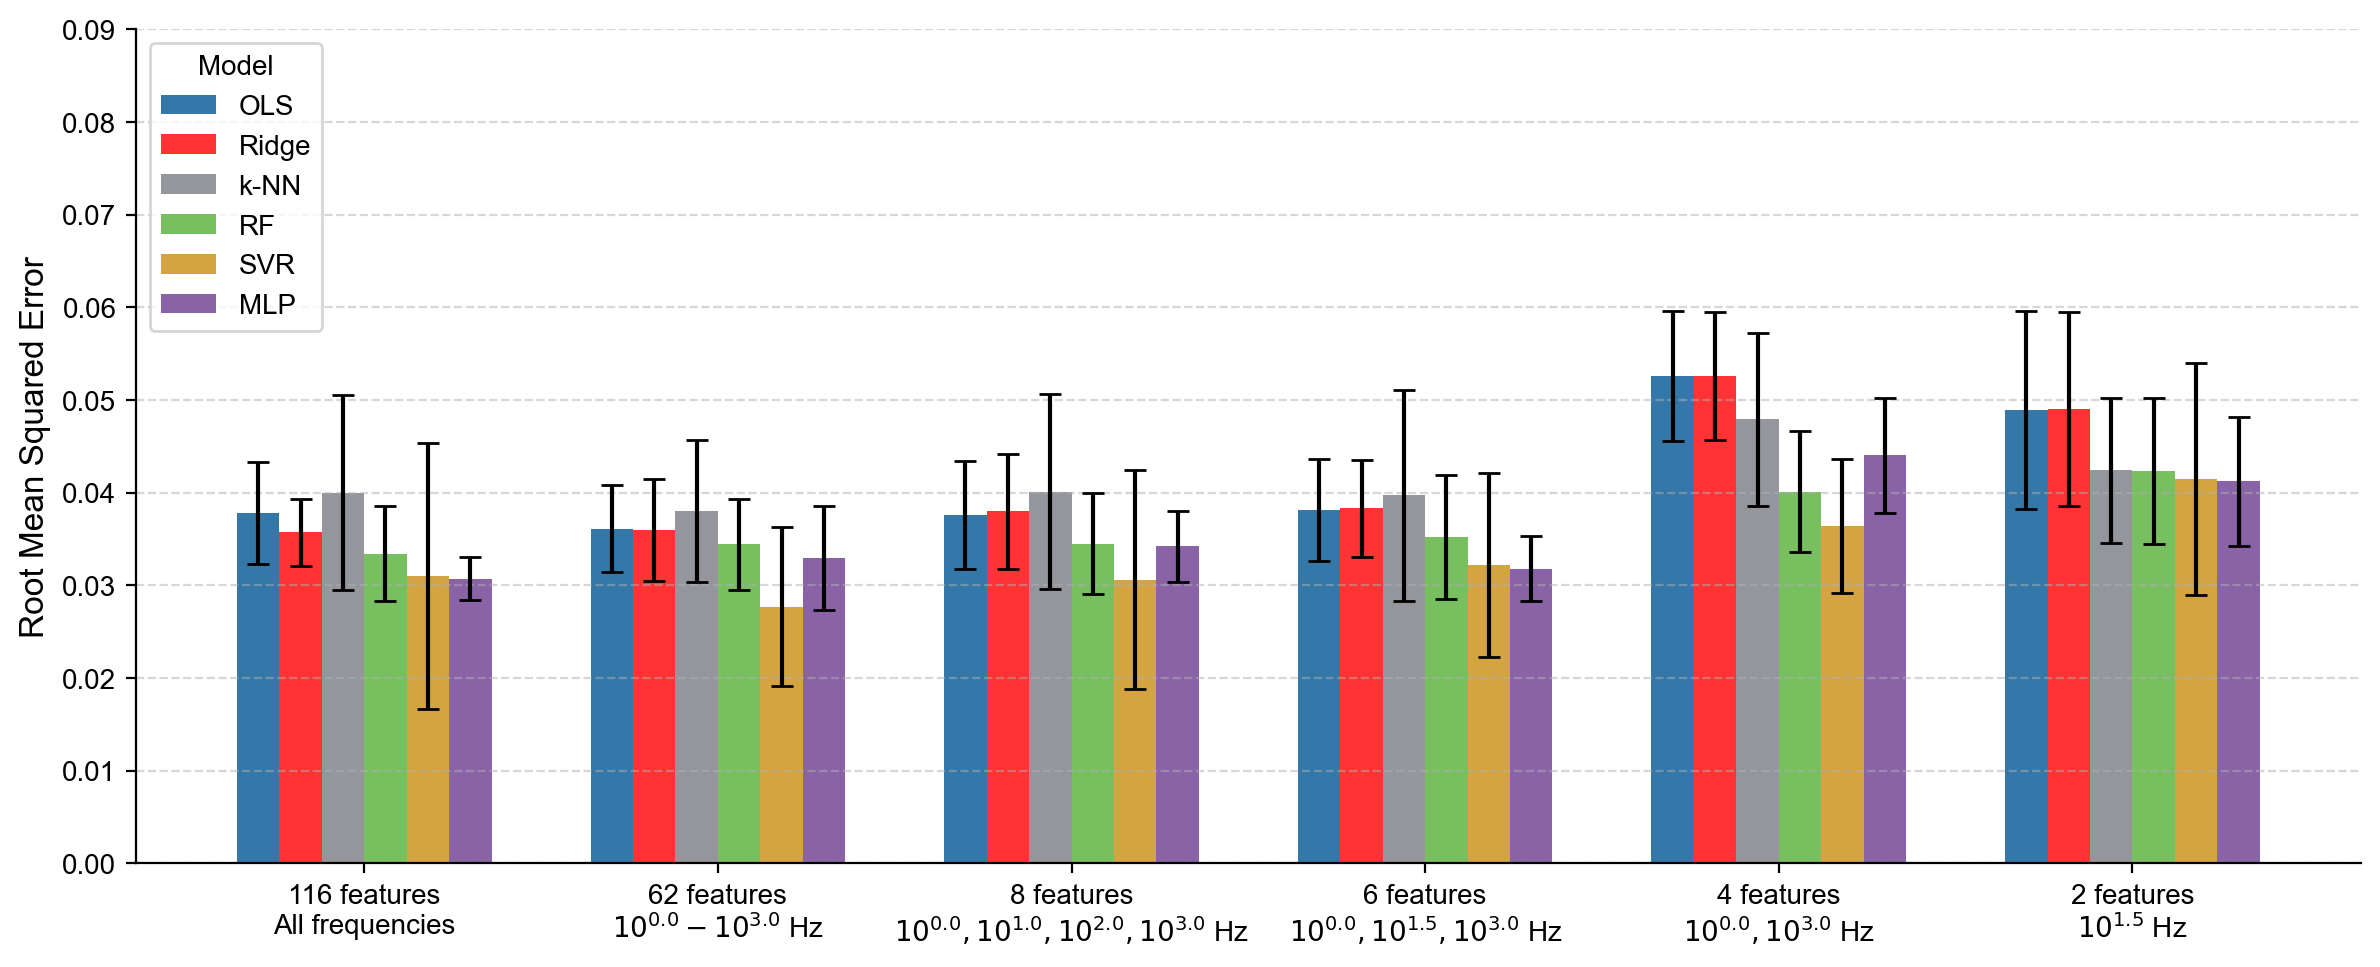

In [ ]:
color = (CMETblue, CFEDred, CMETgrey,  CMETgreen, CMETgold, CMETviolet)

# Paramètres
categories = sampl_freq["Features"]
group_labels = sampl_freq["MLA"]
n_categories = len(categories)
n_groups = len(group_labels)

# Moyennes et erreurs
means = sampl_freq["RMSE"]
errors = sampl_freq["std"]

# Positionnement des barres
x = np.arange(n_categories)
width = 0.12  # largeur des barres
offsets = np.linspace(-width*2.5, width*2.5, n_groups)  # décalages pour grouper

# Création du graphique
fig, ax = plt.subplots(figsize=(12, 5))

for i in range(n_groups):
    ax.bar(
        x + offsets[i],
        means[i],
        width,
        yerr=errors[i],
        capsize=4,
        ecolor='k', 
        label=group_labels[i],
        color=color[i],
        alpha = 0.8
    )

# Mise en forme
ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize = 10)
ax.set_ylim([0, 0.09])
ax.set_ylabel("Root Mean Squared Error", fontsize = 12)
ax.legend(title="Model", loc = 2)
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig("spectral_res.png", dpi = 300, format = "png")
plt.show()

## A posteriori PCA (PCA, Section 4.2 of the paper)

Compact set of impedance features

In [ ]:
col = ['Z_real@10^0.0_Hz', 'Z_imag@10^0.0_Hz', 'Z_real@10^1.5_Hz', 'Z_imag@10^1.5_Hz', 'Z_real@10^3.0_Hz', 'Z_imag@10^3.0_Hz']   
Compact_data = df.loc[:, col].values
Compact_data.shape

(4288, 6)

Principal component analysis on the reduced set of features

In [ ]:
# Prep data
scaler = MinMaxScaler(feature_range = (-1, 1))
Compact_data = scaler.fit_transform(Compact_data)

# PCA computations
pca = PCA(n_components=6, random_state = 42)  
principal_components = pca.fit_transform(Compact_data)

# Results DataFrame
comp_name = ['PC' + str (i+1) for i in range(6)]
pca_df = pd.DataFrame(data=principal_components,
    columns=comp_name)
pca_df["SOH"] = df["SOH"].values

Figure 6 of the paper

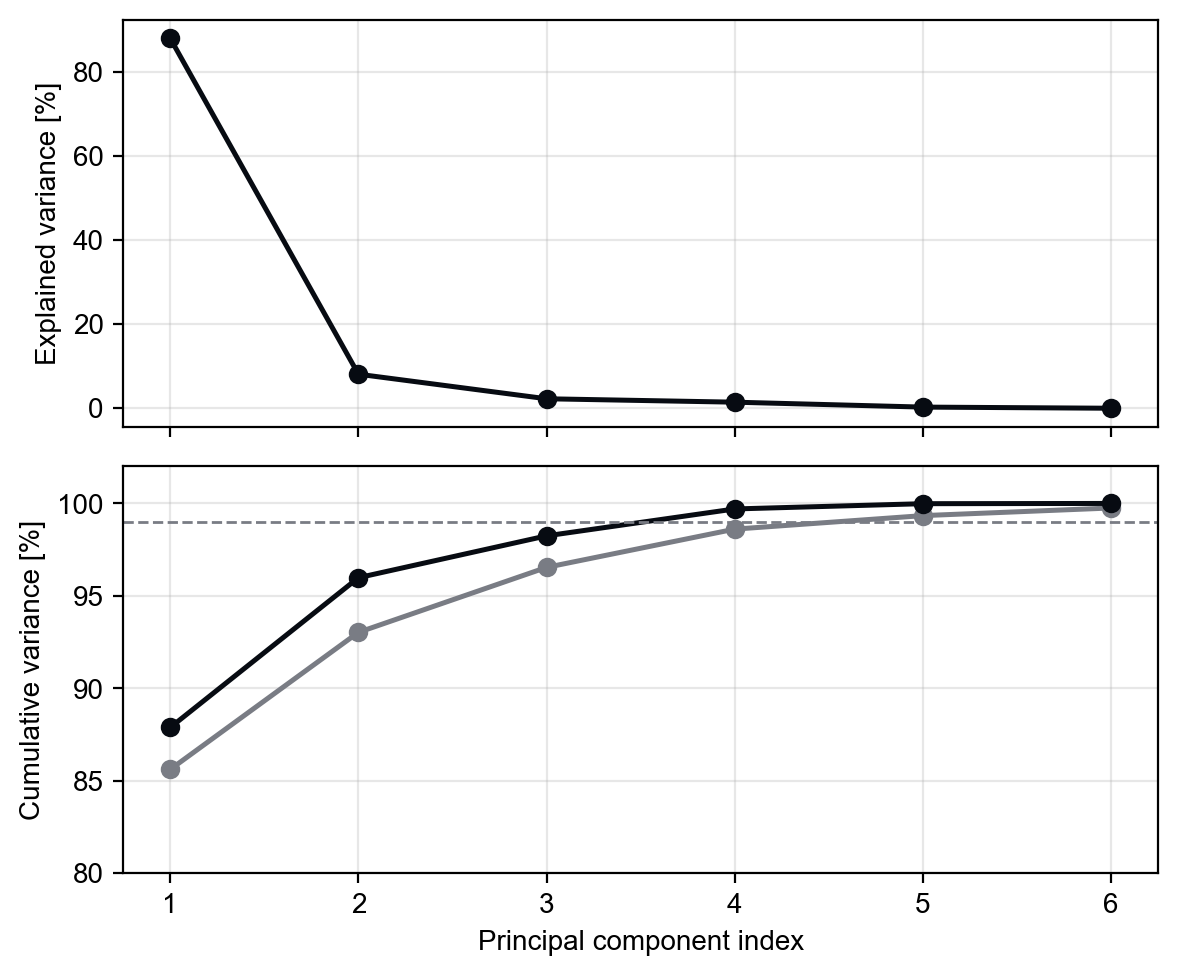

In [ ]:
explained_variance_6 = np.array(pca.explained_variance_ratio_[:6] * 100)
cumulative_variance_6 = np.cumsum(explained_variance_6)
components_6 = np.arange(1, len(explained_variance_6) + 1)

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(6, 5), sharex=True, gridspec_kw={"height_ratios": [1, 1]})

axes[0].plot(components_6, explained_variance_6, marker="o", linewidth=1.8, color=CMETblack)
axes[0].set_ylabel("Explained variance [%]")
axes[0].grid(alpha=0.3)

axes[1].plot(components_116[:6], cumulative_variance_116[:6], marker="o", linewidth=1.8, color=CMETgrey)
axes[1].plot(components_6, cumulative_variance_6, marker="o", linewidth=1.8, color=CMETblack)
axes[1].axhline(99, linestyle="--", linewidth=1, color = CMETgrey)

axes[1].set_xlabel("Principal component index")
axes[1].set_ylabel("Cumulative variance [%]")
axes[1].set_ylim(80, 102)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("post_scree.png", dpi = 300, format = "png")
plt.show()

Figure 5 of the paper

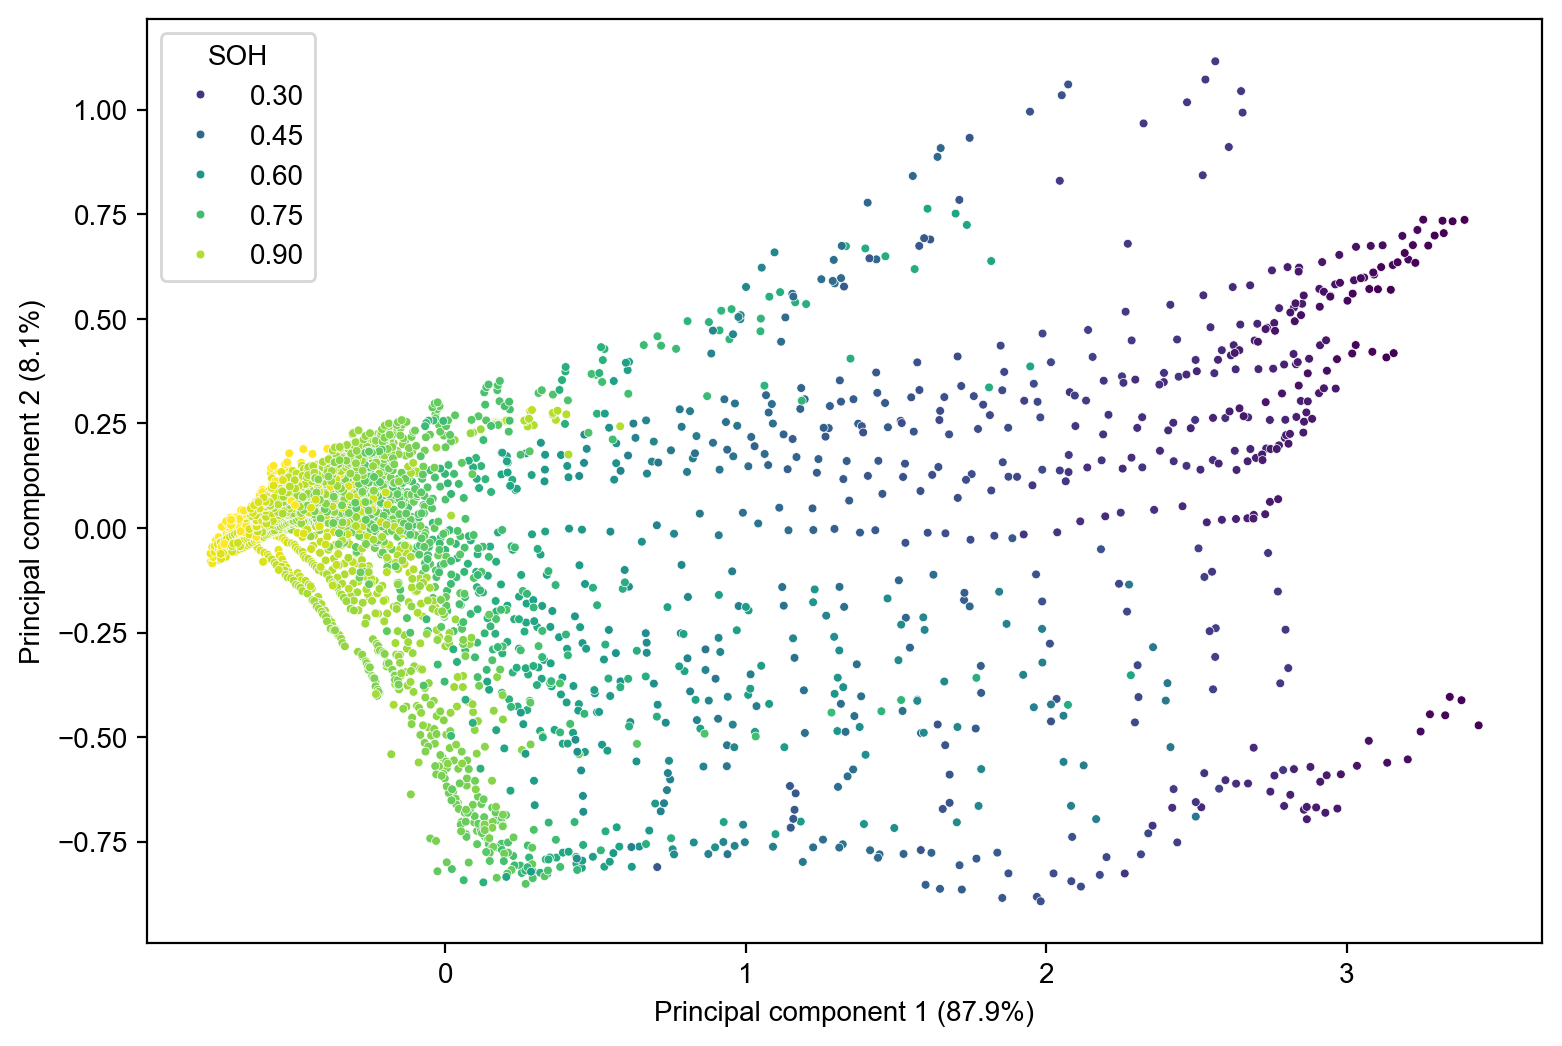

In [ ]:
# Figure article / poster
plt.figure(figsize = (9, 6))
sns.scatterplot(x='PC1', y='PC2', hue = "SOH", s=10 ,palette="viridis", data = pca_df)
plt.xlabel(f'Principal component 1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'Principal component 2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.legend(loc=2, title="SOH")
plt.savefig("post_pca.png", dpi = 300, format = "png")
plt.show()

In [ ]:
print("Kendall's tau:", ss.kendalltau(pca_df["PC1"].values, pca_df["SOH"]))
print("Spearman's rho:", ss.spearmanr(pca_df["PC1"].values, pca_df["SOH"]))

Kendall's tau: SignificanceResult(statistic=np.float64(-0.7123722131228473), pvalue=np.float64(0.0))
Spearman's rho: SignificanceResult(statistic=np.float64(-0.8752492299987311), pvalue=np.float64(0.0))
